In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from HDVClassNet.PP_net import PPNet
from HDVClassNet.VoronoiDecorder import VoronoiDecoder
from Training.MainTrain import TrainingConfig, NN_Trainer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /home/arash/HDV_Shell
Test Step files Directory: /home/arash/HDV_Shell/Testparts
device: cuda
PyVista backend: trame


In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"


shape_path = CircularSurf1

# Meshing controls
# OCC meshing (global fallback for mode="mesh"):
#   - deflection: smaller -> finer OCC mesh
#   - angle: smaller -> finer OCC mesh on curved regions
# Manual UV-grid meshing (used when freeform_mesher="manual" on supported analytic faces):
#   - n_u, n_v: more samples -> finer UV grid mesh
# Gmsh meshing (used for free-form faces when freeform_mesher is "auto" or "gmsh"):
#   - gmsh_size_scale: smaller -> finer mesh, larger -> coarser mesh
#   - gmsh_algorithm: picks the Gmsh 2D meshing algorithm (6 is a solid default)
# Mesher selection:
#   - freeform_mesher="auto": try Gmsh first, then fall back to OpenCascade
#   - freeform_mesher="gmsh": require Gmsh for free-form faces
#   - freeform_mesher="manual": use UV-grid on supported analytic faces, otherwise OpenCascade

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=100,
    n_v=100,
    freeform_mesher="auto",
    gmsh_size_scale=1.0,
    gmsh_algorithm=6,
    device=device,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)

uv = tensors["uv"]
points_xyz = tensors["points_xyz"]
uv = tensors["uv"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
faces_ijk = tensors["faces_ijk"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
pv_faces = tensors["pv_faces"]
bbx_all = list(tensors["BBX"].values())



xmin = min(b["xmin"] for b in bbx_all)
xmax = max(b["xmax"] for b in bbx_all)
ymin = min(b["ymin"] for b in bbx_all)
ymax = max(b["ymax"] for b in bbx_all)
zmin = min(b["zmin"] for b in bbx_all)
zmax = max(b["zmax"] for b in bbx_all)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin


print(f"Number of faces: {tensors['num_faces']}")
print(f"Number of Sampled points: {uv.shape[0]}")
print(f"Global BBX dimensions: dx={dx:.4f}, dy={dy:.4f}, dz={dz:.4f}")

# Visualization follows the selected mesh path because it uses the returned
# `points_xyz` and `pv_faces` tensors directly.
# Increase visual resolution by changing the meshing parameters above:
#   - mode="mesh" + OCC: decrease deflection / angle
#   - mode="mesh" + manual UV: increase n_u / n_v
#   - mode="mesh" + Gmsh: decrease gmsh_size_scale
#   - mode="Sampled_points": increase M_per_face and optionally reduce
#     triangulation_max_edge_rel
viz.visualize_show_Model(points_xyz, pv_faces)


pts = points_xyz.detach().cpu().numpy()
cloud = pv.PolyData(pts)
plotter = pv.Plotter()
plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=6)
plotter.show()

CircularSurf1
MinVolFrac: 0.059099987149238586
Number of faces: 1
Number of Sampled points: 10201
Global BBX dimensions: dx=10.0000, dy=2.2283, dz=3.9712


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x797bf1f53a00_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x797bf1f53b80_1&reconnect=auto" class="pyvi…

In [3]:
fixed_height_shell= 0.2
# shell_problem = ThickenShell(
#     thickness=fixed_height_shell,
#     BC_dir = "y",
#     Load_magnitude=0.0001,
#     voxel_size=0.1,
#     extra_layers=1,
#     tensors=tensors,
#     tangential_tol=0.1,
# )
shell_problem =None
fem =None
# fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
# shell_problem.debug_voxel_stats()
# shell_problem.show_voxels_surface_and_bc()

In [15]:
cfg = TrainingConfig(
    # ============================================================
    # Seed / geometry setup
    # ============================================================
    seed_number=10,
    use_Metric_anisotropy=False,
    fixed_height=fixed_height_shell,
    freeze_w=False,
    w_min=0.0005,
    # Pairwise strut widths now use w_max_ij = 0.8 * seed_distance(i, j).
    use_boundary_attachment=True,
    boundary_vol_weight = 0.5,
    use_boundary_weighted_volume=False,


    # fallback / initialization ranges used by decoder maps
    boundary_attach_alpha = 1.0,
    boundary_attach_width = 0.01,
    boundary_attach_beta = 0.005,

    boundary_attach_width_min=05e-6,
    boundary_attach_width_max=5e-5,

    # PPNet predicts these now
    predict_pair_gating=True,
    predict_boundary_width=True,

    # pair-gating bounds/defaults
    gap_thr_min=0.00,
    gap_thr_max=0.50,
    big_thr_min=0.00,
    big_thr_max=0.60,
    alpha_min=0.01,
    alpha_max=0.20,
    eta_min=0.01,
    eta_max=0.20,

    gap_thr_default=0.15,
    big_thr_default=0.10,
    alpha_default=0.05,
    eta_default=0.05,

    # ============================================================
    # Main geometric / physical target
    # ============================================================
    target_volfrac=0.2,

    # ============================================================
    # Geometric regularization terms
    # ============================================================
    seed_repulsion_sigma=0.08,
    boundary_margin=0.05,

    # ============================================================
    # Core loss weights
    # ============================================================
    lam_fem=0.0,
    lam_vol=20.0,
    lam_rep=0.015,
    lam_bnd=0.0,
    lam_strut=0.0005,
    lam_strut_edge=0.0,
    lam_strut_void=0.2,

    # ============================================================
    # Gate losses
    # ============================================================
    use_gating=False,
    lam_gate_count=0.005,
    lam_gate_binary=0.1,
    gate_target_count=10.0,
    gate_warmup_steps=20,
    gate_binary_warmup_steps=80,
    gate_sharpen_gamma=2.0,
    gate_active_threshold=0.3,
    gate_eps=1e-8,
    gate_bias_init=2.0,

    # ============================================================
    # Learning rates
    # ============================================================
    lr_seed_refine=0.003,
    lr_delta_head=1e-4,
    lr_mlp=2e-4,
    lr_w_head=2e-3,
    lr_h_head=2e-4,
    lr_gate_head=5e-5,
    lr_pair_heads=2e-4,
    lr_boundary_heads=5e-4,

    # ============================================================
    # FEM / normalization
    # ============================================================
    comp_normalize_by=None,
    normalize_losses=False,
    fem_density_floor=0.02,
    skip_bad_fem_steps=True,

    # ============================================================
    # Optimization schedule
    # ============================================================
    num_steps=1000,
    context_vector_size=8,
    log_every=100,
    early_stop_start=5000,
    patience=5000,
    min_delta=1e-10,

    # ============================================================
    # Decoder softness / geometry shaping
    # ============================================================
    tau=0.1,
    beta=0.02,

    # ============================================================
    # Scheduler / training stability
    # ============================================================
    scheduler_milestones=(0.9,),
    scheduler_gamma=0.2,
    Offset_scale=5,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,

    # ============================================================
    # TensorBoard logging
    # ============================================================
    experiment_name=str(Case_name),
    tensorboard_enabled=True,
    tb_log_histograms_every=100,

    # ============================================================
    # Timelapse / visualization
    # ============================================================
    MakeTimelaps=True,
    timelapse_frame_step=10,
    TM_laps_res_u=150,
    TM_laps_res_v=150,
    TM_laps_Thr=0.25,
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
)

print(cfg)

result = trainer.train(
    shape_path,
    face_tensors=tensors["face_tensors"],
)

TensorBoard log dir: runs/CircularSurf1
TrainingConfig(seed_number=10, use_Metric_anisotropy=False, fixed_height=0.2, target_volfrac=0.2, seed_repulsion_sigma=0.08, boundary_margin=0.05, freeze_w=False, use_boundary_attachment=True, boundary_volume_assist=0.1, boundary_attach_width=0.01, boundary_attach_beta=0.005, boundary_attach_alpha=1.0, boundary_attach_width_min=5e-06, boundary_attach_width_max=5e-05, boundary_attach_alpha_min=0.05, boundary_attach_alpha_max=1.0, boundary_attach_beta_min=0.003, boundary_attach_beta_max=0.05, gap_thr_min=0.0, gap_thr_max=0.5, big_thr_min=0.0, big_thr_max=0.6, alpha_min=0.01, alpha_max=0.2, eta_min=0.01, eta_max=0.2, gap_thr_default=0.15, big_thr_default=0.1, alpha_default=0.05, eta_default=0.05, gate_sharpen_gamma=2.0, w_min=0.0005, w_max=0.5, lam_fem=0.0, lam_vol=20.0, lam_rep=0.015, lam_bnd=0.0, lam_strut=0.0005, lam_strut_edge=0.0, lam_strut_void=0.2, comp_normalize_by=None, normalize_losses=False, fem_density_floor=0.02, skip_bad_fem_steps=True

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

New best_step=0 | best_score=0.304753 | vol_eff=0.051341 | comp=0.000000e+00 | w=2.888741e-01
[00000] | active(total/mean)=0/0.00 | gate(min/mean/max)=0.000/0.000/0.000 | L_total=3.0475e-01 | L_vol=1.524e-02 L_fem=0.000e+00 L_strut=0.000e+00 L_rep=2.850e-09 L_bnd=5.460e-01 L_gate=0.000e+00 L_gbin=0.000e+00 | vol=0.276 vol_eff=0.051 (/0.200) comp=0.000e+00 | w=2.889e-01 h=2.000e-01 | gap=2.624e-01 big=3.034e-01 alpha=1.074e-01 eta=1.042e-01 | bw=2.777e-05 ba=1.000e+00 bb=5.000e-03 | theta=0.000e+00 a=0.000e+00 | Lse=7.728e-01 Lsv=0.000e+00 | rho(min/mean/max)=0.000/0.290/0.999 rho_b(min/mean/max)=0.000/0.169/0.998 rho_v(min/mean/max)=0.000/0.139/0.628 | Δrho=0.00e+00 Δseed=0.00e+00 grad_mean=3.25e-02 | fem=OK | best=3.0475e-01@0
[00100] | active(total/mean)=0/0.00 | gate(min/mean/max)=0.000/0.000/0.000 | L_total=1.1854e-01 | L_vol=5.927e-03 L_fem=0.000e+00 L_strut=0.000e+00 L_rep=1.622e-07 L_bnd=5.230e-01 L_gate=0.000e+00 L_gbin=0.000e+00 | vol=0.347 vol_eff=0.119 (/0.200) comp=0.000e+0

In [16]:
trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=0.5, show_solid=False)

Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x79799450f310_17&reconnect=auto" class="pyv…

threshold=0.5 (manual) | solid%=37.536%


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x7978de0a2200_18&reconnect=auto" class="pyv…

(UnstructuredGrid (0x7979942945e0)
   N Cells:    8241
   N Points:   4793
   X Bounds:   0.000e+00, 1.000e+01
   Y Bounds:   -1.274e-01, 2.101e+00
   Z Bounds:   -2.033e+00, 1.939e+00
   N Arrays:   3,
 0.5)

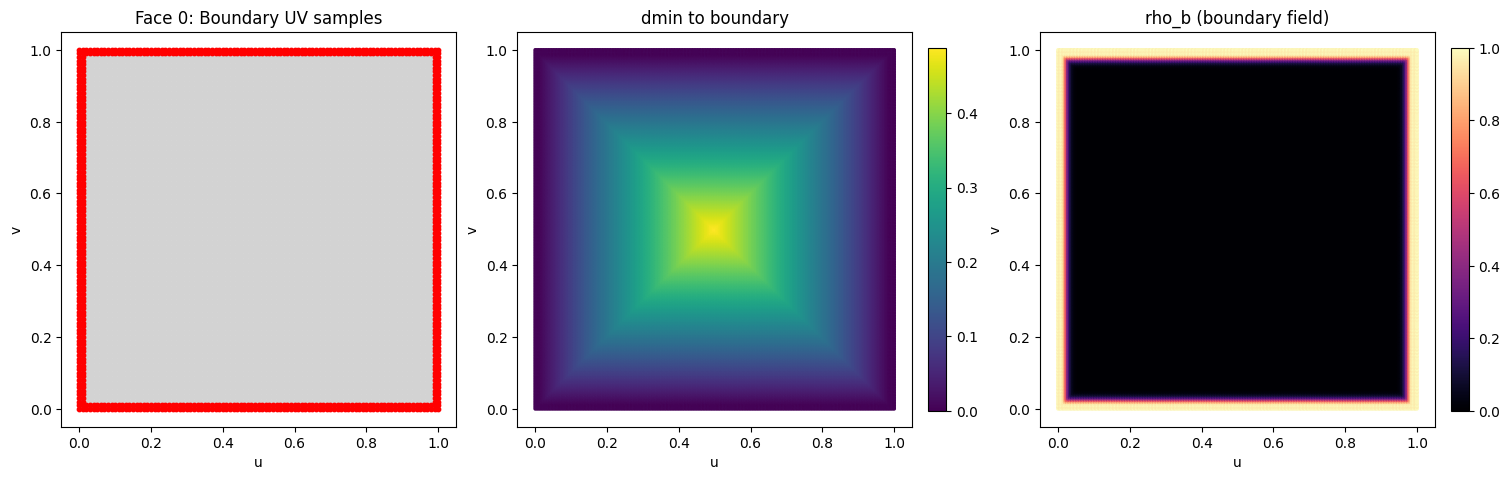

[Face 0] boundary_pts=792 | dmin(min/mean/max)=(0.000e+00/1.557e-01/4.877e-01) | rho_b(min/mean/max)=(0.000e+00/1.088e-01/9.953e-01)


In [6]:
# Increase `dense_factor` for denser UV debug sampling.
dbg = trainer.visualize_boundary_attachment_debug(
    result=result,
    shape_or_path=str(shape_path),
    face_index=0,      # change if needed
    grid_res_u=220,
    grid_res_v=220,
    dense_factor=1.0,
)


In [8]:
# Increase `dense_factor` to get a denser smooth point visualization.
smooth = trainer.visualize_result_final_smooth_points(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.1,
    grid_res_u=300,
    grid_res_v=300,
    dense_factor=1.0,
)

Smooth CAD-native visualization: kept 37330 / 90000 dense points with threshold 0.100


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x797994534790_6&reconnect=auto" class="pyvi…

In [9]:
trainer.visualize_best_seed_activity(result, points_xyz, faces_ijk)
print(result["tensorboard_log_dir"])

Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x79799450f5b0_7&reconnect=auto" class="pyvi…

runs/CircularSurf1


In [10]:
rep = trainer.report_threshold_sweep(
    result=result,
    shape_or_path=str(shape_path),
    thr_values=np.linspace(0.10, 0.45, 36),  # optional
    volfrac_tol=0.03,                        # +/- 3%
    min_boundary_coverage=0.95,
)
thr_star = rep["selected"]["thr"]
print("Selected thr:", thr_star)


[thr_sweep] target=0.2000 | volfrac_cont=0.2432 | min_boundary_cov=0.950 | vol_tol=0.030
thr	volfrac_thr	vol_err	boundary_cov
0.1000	0.4148	0.2148	1.0000
0.1100	0.4121	0.2121	1.0000
0.1200	0.3999	0.1999	1.0000
0.1300	0.3976	0.1976	1.0000
0.1400	0.3957	0.1957	1.0000
0.1500	0.3936	0.1936	1.0000
0.1600	0.3917	0.1917	1.0000
0.1700	0.3812	0.1812	1.0000
0.1800	0.3779	0.1779	1.0000
0.1900	0.3761	0.1761	1.0000
0.2000	0.3744	0.1744	1.0000
0.2100	0.3728	0.1728	1.0000
0.2200	0.3710	0.1710	1.0000
0.2300	0.3694	0.1694	1.0000
0.2400	0.3579	0.1579	1.0000
0.2500	0.3558	0.1558	1.0000
0.2600	0.3541	0.1541	1.0000
0.2700	0.3524	0.1524	1.0000
0.2800	0.3508	0.1508	1.0000
0.2900	0.3493	0.1493	1.0000
0.3000	0.3480	0.1480	1.0000
0.3100	0.3365	0.1365	1.0000
0.3200	0.3350	0.1350	1.0000
0.3300	0.3336	0.1336	1.0000
0.3400	0.3325	0.1325	1.0000
0.3500	0.3313	0.1313	1.0000
0.3600	0.3236	0.1236	1.0000
0.3700	0.3187	0.1187	1.0000
0.3800	0.3176	0.1176	1.0000
0.3900	0.2871	0.0871	1.0000
0.4000	0.2610	0.0610	0.1692
0.4100

In [20]:
# Increase `dense_factor` to refine the CAD-native smooth surface display.
out = trainer.visualize_result_final_smooth_surface_pyvista(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.55,
    grid_res_u=300,
    grid_res_v=300,
    dense_factor=1.0,
)
print(out["thr_used"], out["volfrac_thr"])

[smooth_surface] thr=0.5500 | volfrac_cont(rho)=0.3372 | volfrac_thr(binary)=0.3622 | target=0.2000


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x7979861c43a0_29&reconnect=auto" class="pyv…

0.55 0.3621888756752014


In [17]:
for t in [0.01,0.05,0.1,0.15,0.25,0.35,0.45,0.5]:    
    out = trainer.visualize_result_final_smooth_surface_pyvista(
        result=result,
        shape_or_path=str(shape_path),
        thr=t ,
        grid_res_u=300,
        grid_res_v=300,
        dense_factor=1.0,
    )
    print(out["thr_used"], out["volfrac_thr"])



[smooth_surface] thr=0.0100 | volfrac_cont(rho)=0.3372 | volfrac_thr(binary)=0.5772 | target=0.2000


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x7978de0a3e20_19&reconnect=auto" class="pyv…

0.01 0.5772333145141602
[smooth_surface] thr=0.0500 | volfrac_cont(rho)=0.3372 | volfrac_thr(binary)=0.5015 | target=0.2000


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x7978de0a1e40_20&reconnect=auto" class="pyv…

0.05 0.5015110969543457
[smooth_surface] thr=0.1000 | volfrac_cont(rho)=0.3372 | volfrac_thr(binary)=0.4710 | target=0.2000


...

0.35 0.3976111114025116
[smooth_surface] thr=0.4500 | volfrac_cont(rho)=0.3372 | volfrac_thr(binary)=0.3802 | target=0.2000


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x797994534eb0_25&reconnect=auto" class="pyv…

0.45 0.38018888235092163
[smooth_surface] thr=0.5000 | volfrac_cont(rho)=0.3372 | volfrac_thr(binary)=0.3755 | target=0.2000


Widget(value='<iframe src="http://localhost:36109/index.html?ui=P_0x797994445690_26&reconnect=auto" class="pyv…

0.5 0.37547776103019714


In [13]:
%load_ext tensorboard
%tensorboard --logdir runs